## Generate new intersection.xml from old one 

In [117]:
# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

from commonroad.common.file_writer import CommonRoadFileWriter
from commonroad.common.file_writer import OverwriteExistingFile
from commonroad.scenario.scenario import Location
from commonroad.scenario.scenario import Tag
import copy

# generate path of the file to be opened
#file_path = "DEU_Speyer-2_2_T-1.xml" #simple 
#file_path = "test_reading_intersection_traffic_sign.xml" #simple
file_path = "USA_Lanker-2_1_T-1.xml" #not adjacent complex 
#file_path = "USA_Peach-4_8_T-1.xml"  #adjacent complex
#file_path = "ZAM_Tjunction-1_19_T-1.xml" #single T
#file_path = "ESP_Monzon-2_4_T-1.xml" # two T 
#file_path = "DEU_Muehlhausen-2_2_T-1.xml" #multi T

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

author = 'Max Mustermann'
affiliation = 'Technical University of Munich, Germany'
source = ''
tags = {Tag.CRITICAL, Tag.INTERSTATE}

#scenario_ = copy.deepcopy(scenario)
#fw = CommonRoadFileWriter(scenario_, planning_problem_set, author, affiliation, source, tags)

#filename = "complex_intersection.xml"
#fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True, key="roadNetwork")
#fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True, key="obstaclesPlanning")
#fw.write_to_file(filename, OverwriteExistingFile.ALWAYS, True)

## Check out complex intersection 

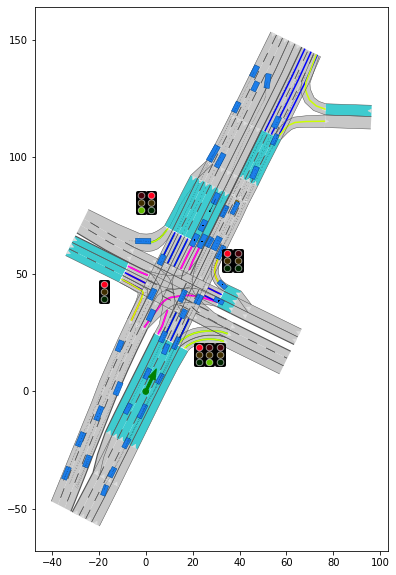

In [118]:
import os
import matplotlib.pyplot as plt
from IPython import display

# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

# generate path of the file to be opened
#file_path = "complex_intersection.xml"

# read in the scenario and planning problem set
#scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()

In [93]:
print(len(scenario.lanelet_network.intersections))
print(scenario.lanelet_network.intersections[0].intersection_id)
print(scenario.lanelet_network.intersections[0].crossings)

2
3840
set()


In [94]:
intersections = scenario.lanelet_network.intersections
intersection_list = []

for i in range(1):
    intersection_list.append(intersections[i])

In [95]:
len(intersection_list)

1

In [96]:
import numpy as np

def get_angle(v1: np.ndarray, v2:np.ndarray) -> float:
    """
    Get clockwise angle between vectors
    :param v1: one vector
    :type v1: np.ndarray
    :param v2: another vector
    :type v2: np.ndarray
    :return: clockwise angle between vectors in degrees
    :rtype: float
    """
    x = [v1[0], v2[0]]
    y = [v1[1], v2[1]]
    angles = np.arctan2(y, x) + np.pi
    diff1 = angles[0] - angles[1]
    angle = diff1 / np.pi * 180
    return angle

In [97]:
# threshold which is used to determine if a successor of an incoming lane is considered as straight
INTERSECTION_STRAIGHT_THRESHOLD = 35.0

def compute_left_list(incomings, incomings_id):
    """
    Find clockwise order for the incomings

    :param incomings: incomings of one intersection
    :param incomings_id: List of the id of the incomings
    :return: incomings in clockwise order
    """

    # choose a reference incoming vector    
    ref = incomings[0]['waypoints'][0] - incomings[0]['waypoints'][-1]
    angles = [(0, 0)]

    # calculate all incoming angle from the reference incoming vector
    for index in range(1, len(incomings)):
        new_v = incomings[index]['waypoints'][0] - incomings[index]['waypoints'][-1]
        angle = get_angle(ref, new_v)
        if angle < 0:
            angle += 360
        angles.append((index, angle))

    # sort the angles from the reference to go clockwise
    angles.sort(key=lambda tup: tup[1])
    prev = -1

    # take the incomings which have less than 90 degrees in between
    for index in range(0, len(incomings)):
        angle = angles[index][1] - angles[prev][1]
        if angle < 0:
            angle += 360

        # add is_left_of relation if angle is less than intersection straight treshold
        if angle <= 180 - INTERSECTION_STRAIGHT_THRESHOLD:
            # is left of the previous incoming
            is_left_of = angles[prev][0]
            data_index = angles[index][0]
            incomings[data_index].update({'isLeftOf': incomings_id[is_left_of]})

        prev = index

    return incoming_data

In [104]:
incoming_list = []
count_int = 0
incomings = scenario.lanelet_network.intersections[count_int].incomings
network = scenario.lanelet_network

for i in range(len(incomings)):
    incoming_list.append(incomings[i].incoming_id)
            
#compute_left_list(incomings, incoming_list)

In [112]:
#reference vector of incomings
index = 0
lanelets = incomings[index].incoming_lanelets
front_node, back_node = [],[]

for laneId in lanelets:
    lane = network.find_lanelet_by_id(laneId)
    front_node.append(lane.center_vertices[-1])
    if len(lane.center_vertices)>4:
        back_node.append(lane.center_vertices[-4])
    else:
        back_node.append(lane.center_vertices[0])

front_node.sort(key=lambda tup: tup[0])
back_node.sort(key=lambda tup: tup[0])

ref = 0.5*(front_node[-1] + front_node[0]) - 0.5*(back_node[-1] + back_node[0])

[12.749725 25.233575]


In [74]:
from commonroad.geometry.shape import Rectangle
from commonroad.geometry.polyline_util import compute_polyline_orientations
from numpy.linalg import norm

def is_adjacent_lanelet(network, lanelet_id, incoming_id):
    lane = network.find_lanelet_by_id(lanelet_id)
    
    orientation = compute_polyline_orientations(lane.center_vertices)
    center = lane.center_vertices[0]
    lane_width = norm(lane.right_vertices[0] - lane.left_vertices[0])

    enlarged_shape = Rectangle(length=2*lane_width, width=4*lane_width, 
                               center=center, orientation=orientation[0])
    adjacent_lanelets = network.find_lanelet_by_shape(enlarged_shape)
    #print(adjacent_lanelets)
    
    incoming_index = incoming_list.index(incoming_id)
    incoming_lanelets = network.intersections[0].incomings[incoming_index].incoming_lanelets
    #print(incoming_lanelets)
    
    if set(adjacent_lanelets) & set(incoming_lanelets):
        return True
    else:
        return False

In [86]:
incoming_list = []
count_int = 0
while(count_int < len(intersection_list)):
    incomings = scenario.lanelet_network.intersections[count_int].incomings
    if (len(incomings) == 4):
        
        left_list = [incomings[0].incoming_id]

        for i in range(len(incomings)):
            incoming_list.append(incomings[i].incoming_id)
        
        count = 0
        while(count < len(incomings)):
            left_list.append(incomings[incoming_list.index(left_list[count])].left_of)
            count += 1
        left_list = list(reversed(left_list))
    count_int +=1

print(incoming_list)
print(left_list)
print(incomings[3].incoming_lanelets)
print(incomings[3].successors_right)
print(incomings[3].successors_left)
print(incomings[3].successors_straight)

[]
[302, 303, 305, 304, 302]


IndexError: list index out of range

In [75]:
network = scenario.lanelet_network

for index in range(len(incoming_list)):
    straight, left, right = [], [], []
    
    left_list_index = left_list.index(incoming_list[index])
    if (left_list_index + 2) < len(incomings):
        opposite_index = incoming_list.index(left_list[left_list_index + 2])
    else:
        opposite_index = incoming_list.index(left_list[left_list_index - 2])
    left_index = incoming_list.index(left_list[left_list_index + 1])
    print(left_index, opposite_index)
    
    #straight
    for item in (incomings[index].successors_straight):
        lane_straight = network.find_lanelet_by_id(item)#618,620
        succ_lane = network.find_lanelet_by_id(lane_straight.successor[0])#660,662

        # single straight lane in simple scenario
        if is_adjacent_lanelet(network, lane_straight.successor[0], incoming_list[opposite_index]):
            straight.append(lane_straight.lanelet_id)
        
        else:
            lane_straight_2 = network.find_lanelet_by_id(lane_straight.successor[0])#660,662
            succ_lane_2 = network.find_lanelet_by_id(lane_straight_2.successor[0])#638,640

            if is_adjacent_lanelet(network, lane_straight_2.successor[0], incoming_list[opposite_index]):
                straight.append(lane_straight_2.lanelet_id)

            else:
                lane_straight_3 = network.find_lanelet_by_id(lane_straight_2.successor[0])#638/640
                succ_lane_3 = network.find_lanelet_by_id(lane_straight_3.successor[0])#511,514

                # multi straight lane in complex scenario
                if succ_lane_3.adj_left_same_direction:
                    succ_lane_3_adj = network.find_lanelet_by_id(succ_lane_3.adj_left)#511

                    if is_adjacent_lanelet(network, succ_lane_3.adj_left, incoming_list[opposite_index]):
                        straight.append(lane_straight_3.lanelet_id)

                    elif is_adjacent_lanelet(network, succ_lane_3_adj.adj_left, incoming_list[opposite_index]):
                        straight.append(lane_straight_3.lanelet_id)

                elif is_adjacent_lanelet(network, lane_straight_3.successor[0], incoming_list[opposite_index]):
                    straight.append(lane_straight_3.lanelet_id)
    
    #right
    for item in (incomings[index].successors_right):
        right.append(item)
    
    #left
    for item in (incomings[index].successors_left):
        lane_left = network.find_lanelet_by_id(item)#673,671/665/834

        for i in range(len(lane_left.successor)):
            succ_lane = network.find_lanelet_by_id(lane_left.successor[i]) #672,670/664/648,634

            # single left lane in simple scenario
            if is_adjacent_lanelet(network, lane_left.successor[i], incoming_list[left_index]):
                left.append(lane_left.lanelet_id)

            elif len(succ_lane.successor) != 0:
                lane_left_2 = network.find_lanelet_by_id(lane_left.successor[i])#672,670/664/648
                succ_lane_2 = network.find_lanelet_by_id(succ_lane.successor[0])#452,638/522/616

                if is_adjacent_lanelet(network, lane_left_2.successor[0], incoming_list[left_index]):
                    left.append(lane_left_2.lanelet_id)

                elif succ_lane_2.adj_left_same_direction:
                    if is_adjacent_lanelet(network, succ_lane_2.adj_left, incoming_list[left_index]):
                        left.append(lane_left_2.lanelet_id)

                else:
                    lane_left_3 = network.find_lanelet_by_id(lane_left_2.successor[0])#638
                    succ_lane_3 = network.find_lanelet_by_id(lane_left_3.successor[0])#511

                    if is_adjacent_lanelet(network, lane_left_3.successor[0], incoming_list[left_index]):
                        left.append(lane_left_3.lanelet_id)
    
    print(straight, left, right)

1 3
[22] [20] [26]
3 2
[24] [28] [30]
0 1
[23] [31] [27]
2 0
[21] [25] [29]


## Check out simple intersection details  

In [ ]:
import os
import matplotlib.pyplot as plt
from IPython import display

# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

# generate path of the file to be opened
file_path = "simple_intersection.xml"

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()

In [ ]:
scenario.lanelet_network.intersections[0].intersection_id

In [ ]:
print(scenario.lanelet_network.intersections[0].crossings)
incomings = scenario.lanelet_network.intersections[0].incomings

for i in range(len(incomings)):
    print(incomings[i].incoming_id)

In [ ]:
print(incomings[3].outgoings_right)
print(incomings[3].outgoings_left)
print(incomings[1].outgoings_straight)
#print(incomings[1].left_of)
print(incomings[1].incoming_lanelets)

In [ ]:
for i in range(18):
    scenario.lanelet_network.remove_lanelet(lanelets[i].lanelet_id)

for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()